In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/smart_phone_addiction.csv")

In [3]:
df.drop(columns=["id"],inplace=True)

In [4]:
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [5]:
df.shape

(691369, 13)

In [6]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


<Axes: xlabel='gender', ylabel='count'>

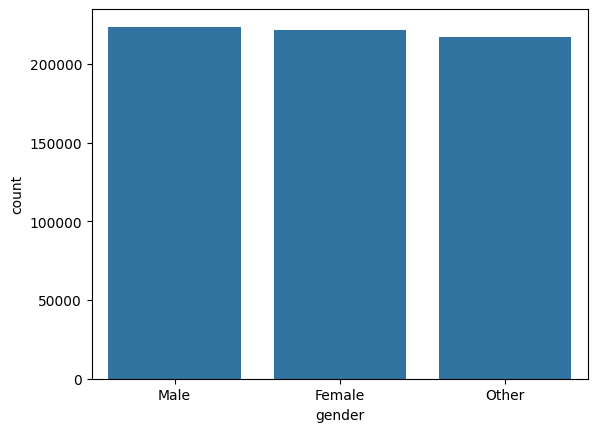

In [7]:
sns.countplot(df,x="gender")

<Axes: xlabel='stress_level', ylabel='count'>

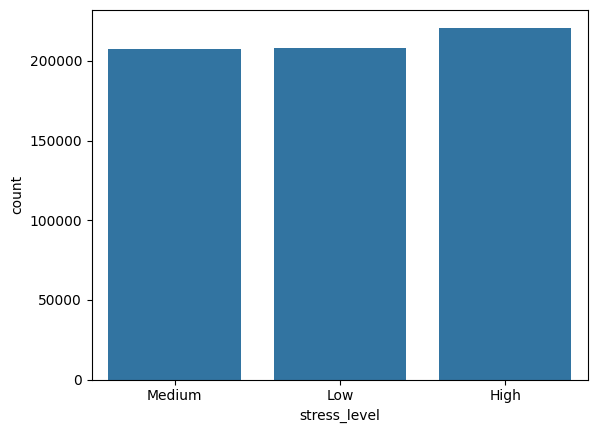

In [8]:
sns.countplot(df,x="stress_level")

In [9]:
numerical_cols = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'age'
]


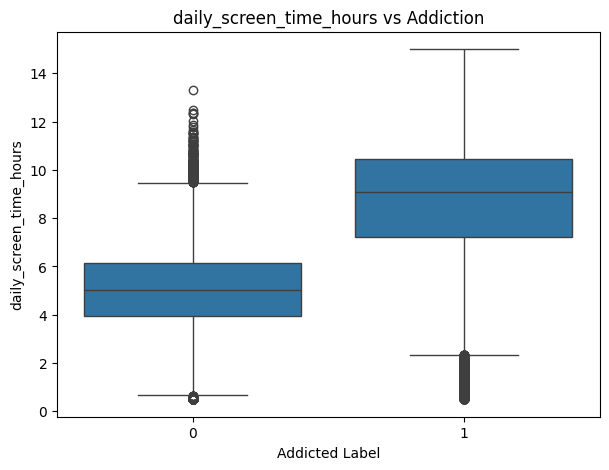

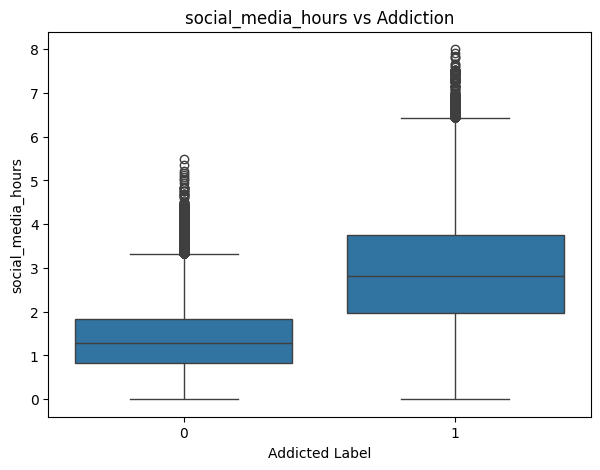

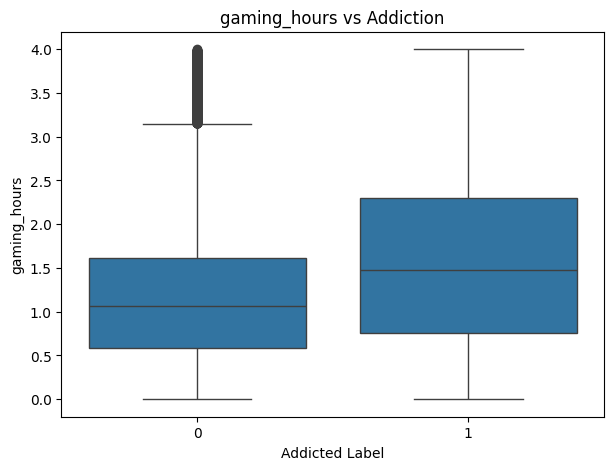

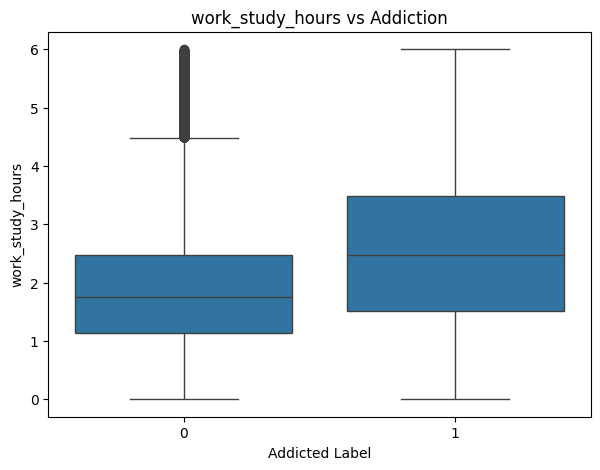

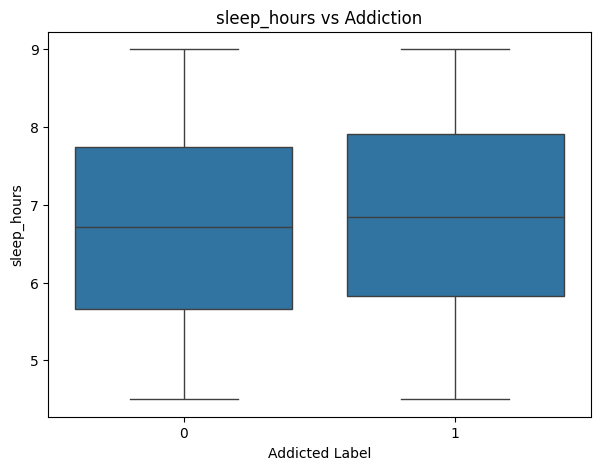

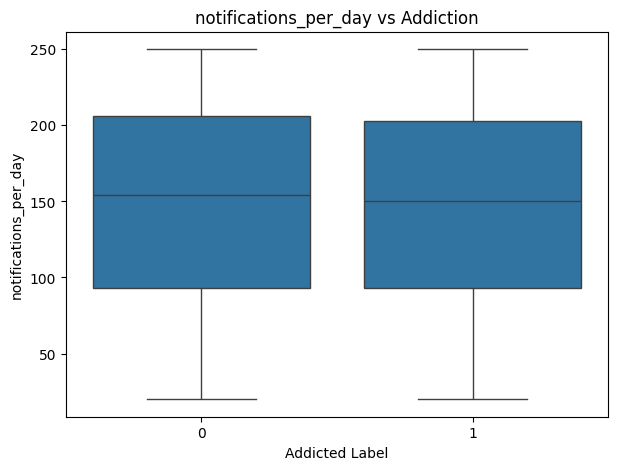

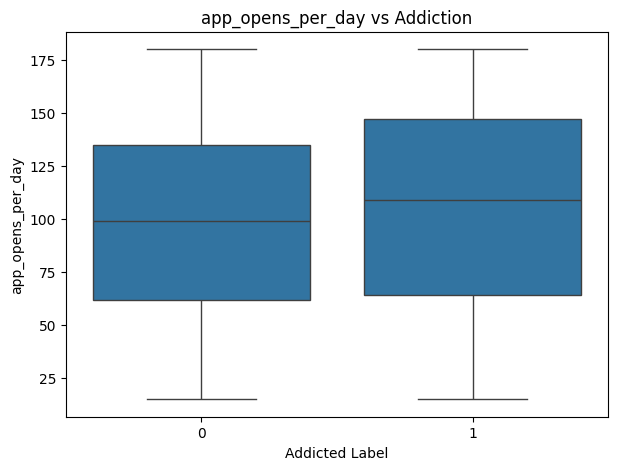

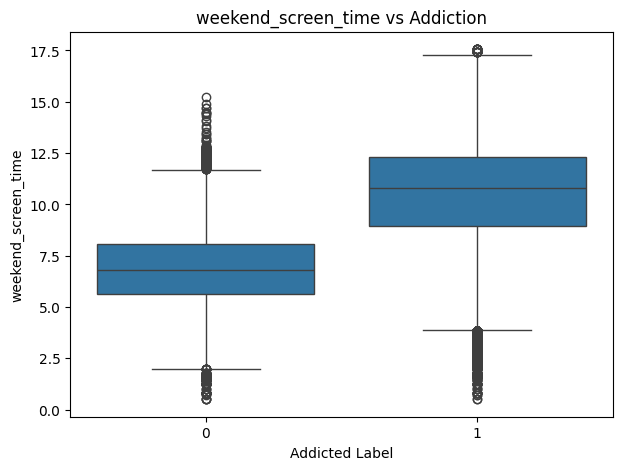

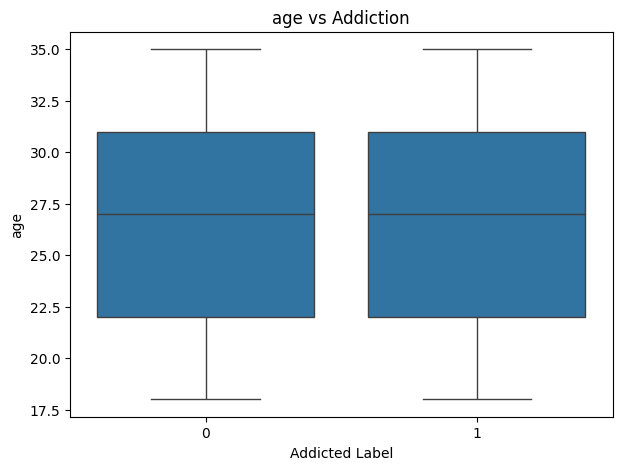

In [10]:

for col in numerical_cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='addicted_label', y=col)
    plt.title(f'{col} vs Addiction')
    plt.xlabel('Addicted Label')
    plt.ylabel(col)
    plt.show()

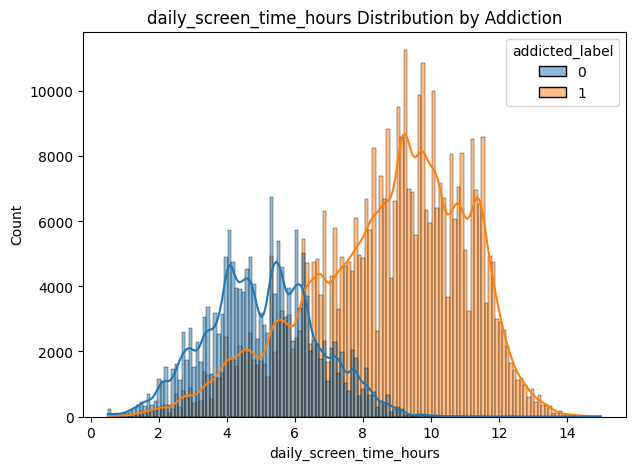

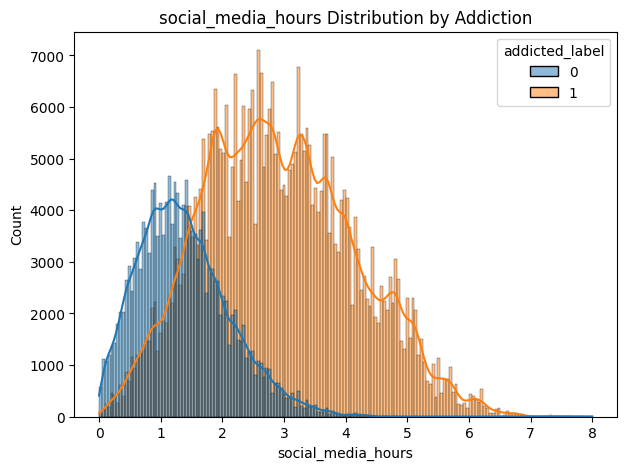

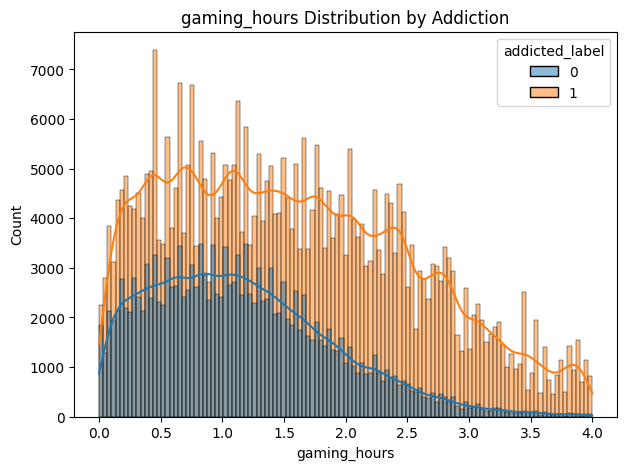

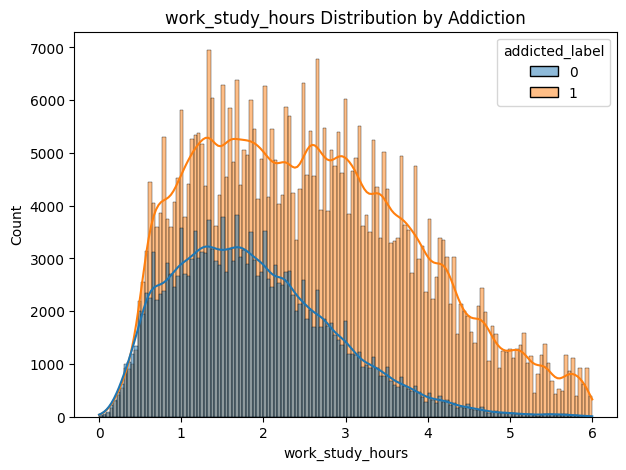

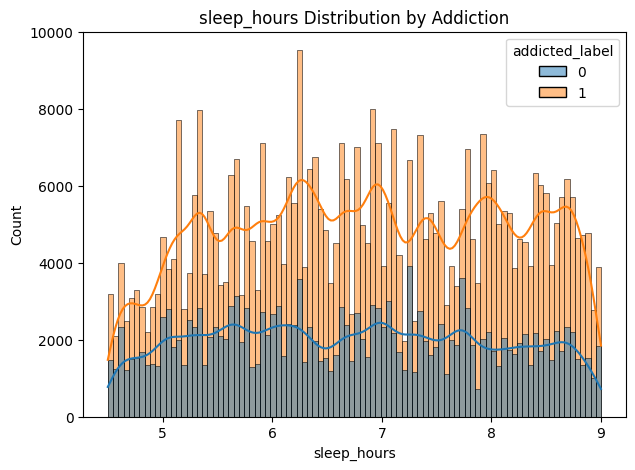

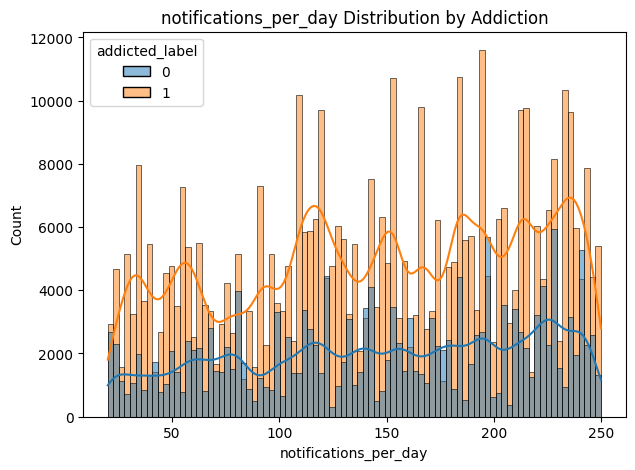

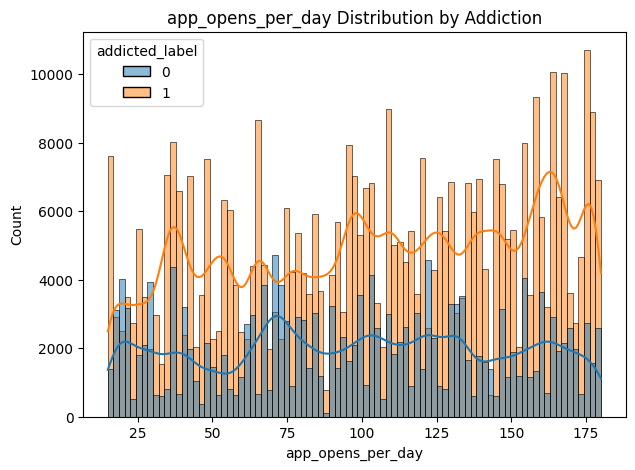

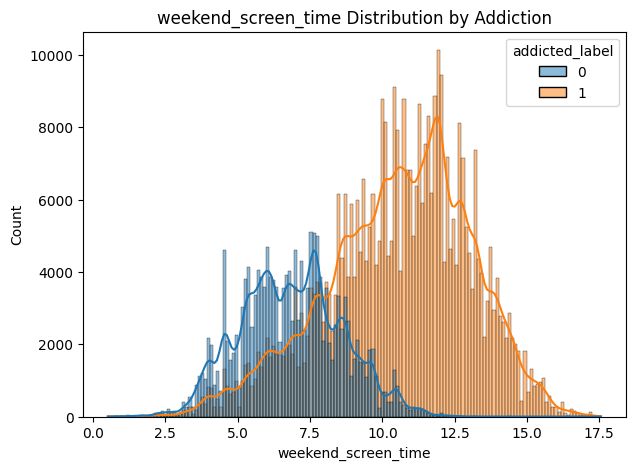

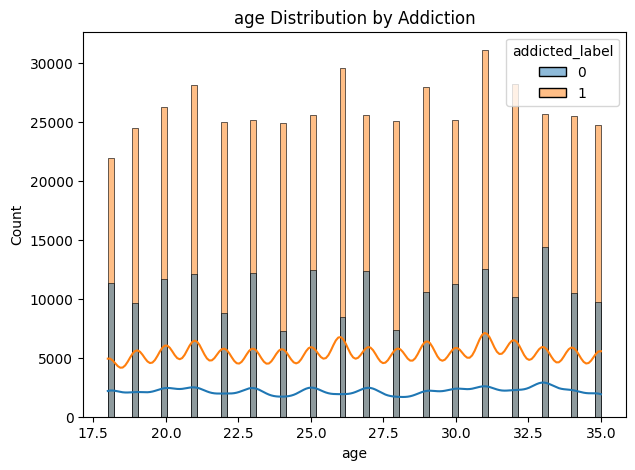

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(7, 5))
    sns.histplot(data=df, x=col, hue='addicted_label', kde=True)
    plt.title(f'{col} Distribution by Addiction')
    plt.show()

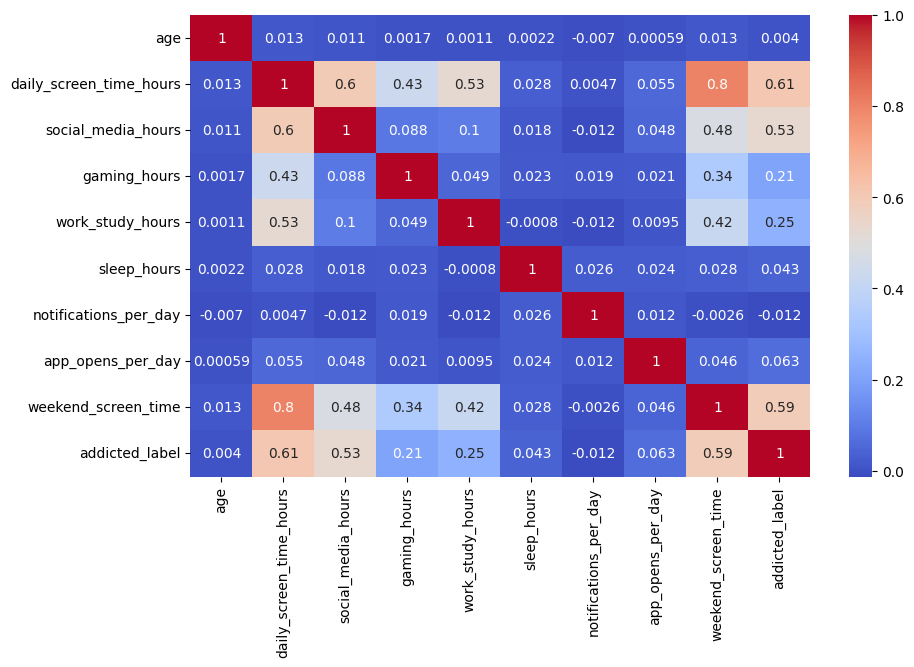

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [13]:
df.dropna(thresh=8,inplace=True)

In [14]:
df.isna().sum()

age                         27095
daily_screen_time_hours     90608
social_media_hours         128251
gaming_hours               121150
work_study_hours            48878
sleep_hours                 41065
notifications_per_day       63357
app_opens_per_day           76178
weekend_screen_time        106522
gender                      27161
stress_level                51288
academic_work_impact        40902
addicted_label                  0
dtype: int64

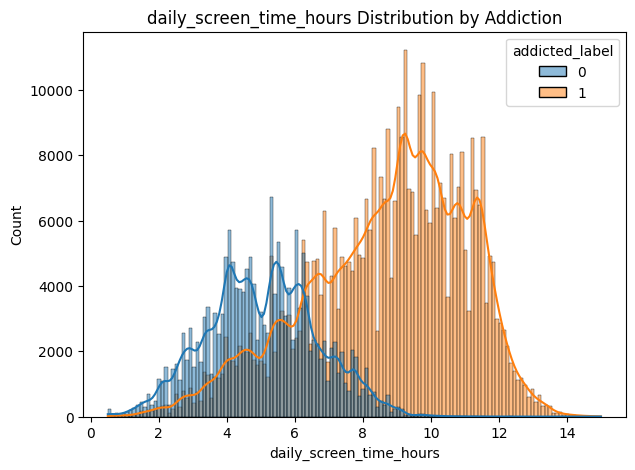

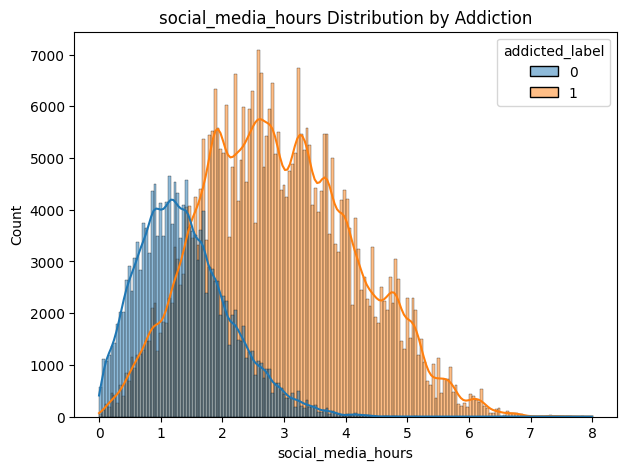

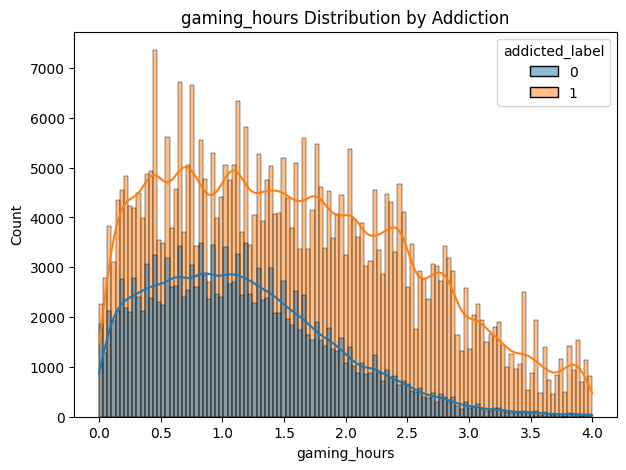

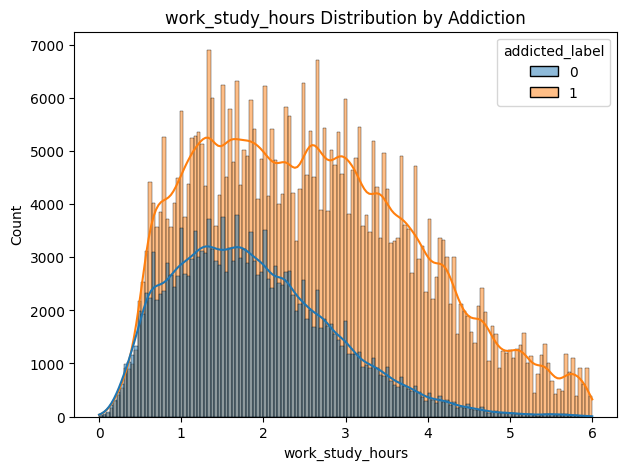

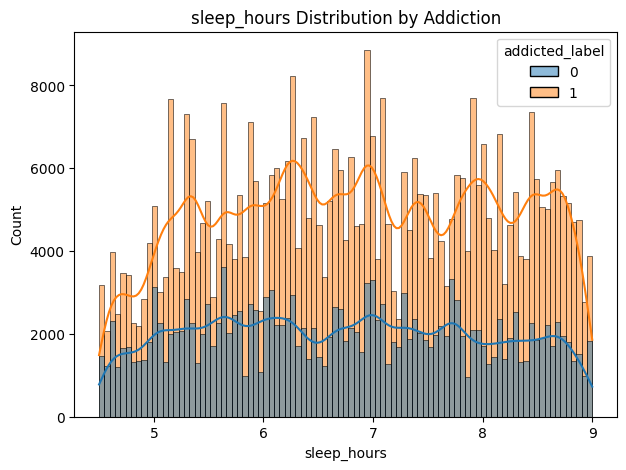

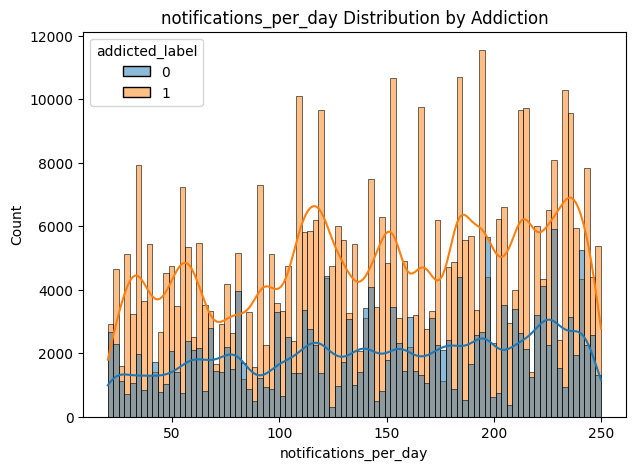

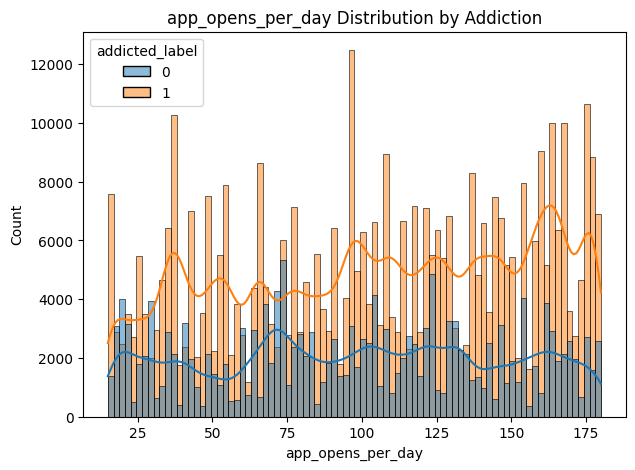

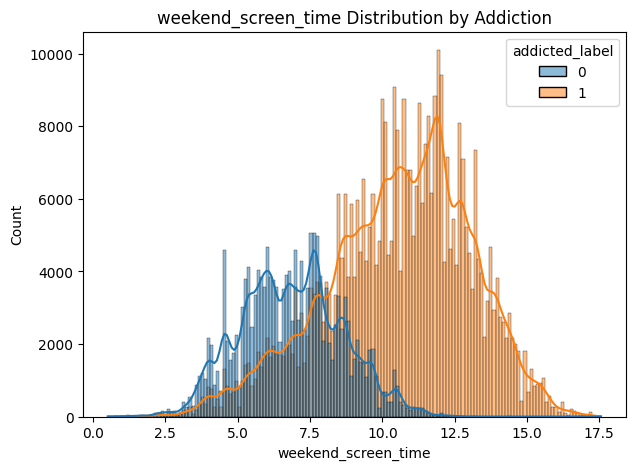

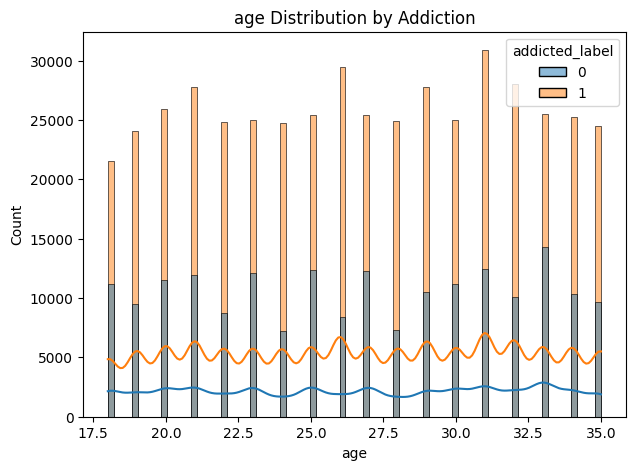

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(7, 5))
    sns.histplot(data=df, x=col, hue='addicted_label', kde=True)
    plt.title(f'{col} Distribution by Addiction')
    plt.show()

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler





scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])

imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

imputed_data = imputer.fit_transform(scaled_data)

# Convert back to original scale
imputed_data = scaler.inverse_transform(imputed_data)

# Put values back into dataframe
df[numerical_cols] = imputed_data

/Users/bhijanbastola/Desktop/intern/100/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
#Feature Engineering
df["entertainment_hours"] = (
    df["social_media_hours"] +
    df["gaming_hours"]
)


df["entertainment_ratio"] = (
    df["entertainment_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)


df["social_media_ratio"] = (
    df["social_media_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)


df["gaming_ratio"] = (
    df["gaming_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)


df["work_study_ratio"] = (
    df["work_study_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)


df["weekend_screen_ratio"] = (
    df["weekend_screen_time"] /
    (df["daily_screen_time_hours"] + 0.01)
)


df["weekend_screen_difference"] = (
    df["weekend_screen_time"] -
    df["daily_screen_time_hours"]
)


df["recreational_to_work_ratio"] = (
    df["entertainment_hours"] /
    (df["work_study_hours"] + 0.01)
)


df["social_gaming_interaction"] = (
    df["social_media_hours"] *
    df["gaming_hours"]
)


df["sleep_screen_ratio"] = (
    df["sleep_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

In [18]:
df.isna().sum()

age                               0
daily_screen_time_hours           0
social_media_hours                0
gaming_hours                      0
work_study_hours                  0
sleep_hours                       0
notifications_per_day             0
app_opens_per_day                 0
weekend_screen_time               0
gender                        27161
stress_level                  51288
academic_work_impact          40902
addicted_label                    0
entertainment_hours               0
entertainment_ratio               0
social_media_ratio                0
gaming_ratio                      0
work_study_ratio                  0
weekend_screen_ratio              0
weekend_screen_difference         0
recreational_to_work_ratio        0
social_gaming_interaction         0
sleep_screen_ratio                0
dtype: int64

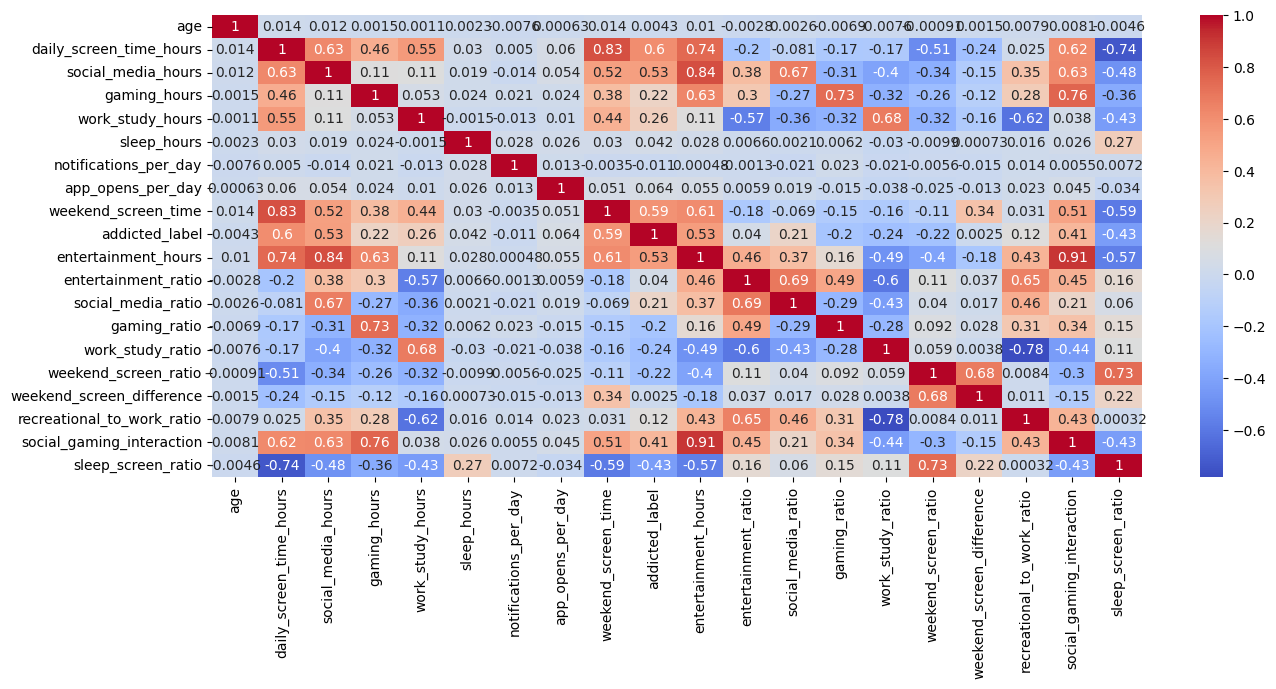

In [19]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

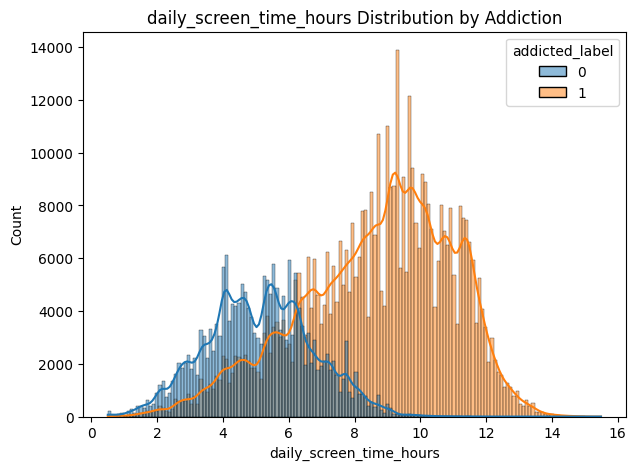

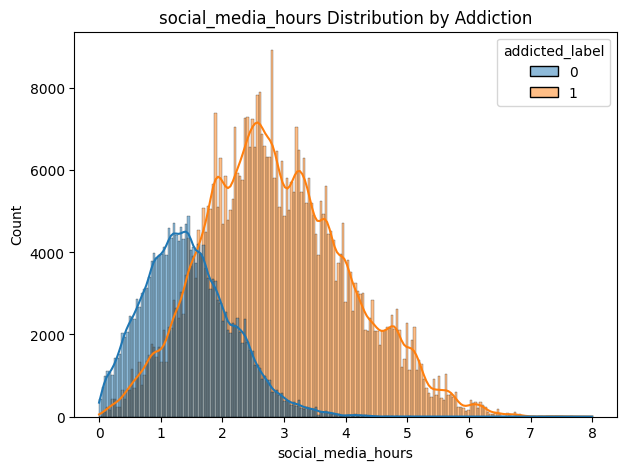

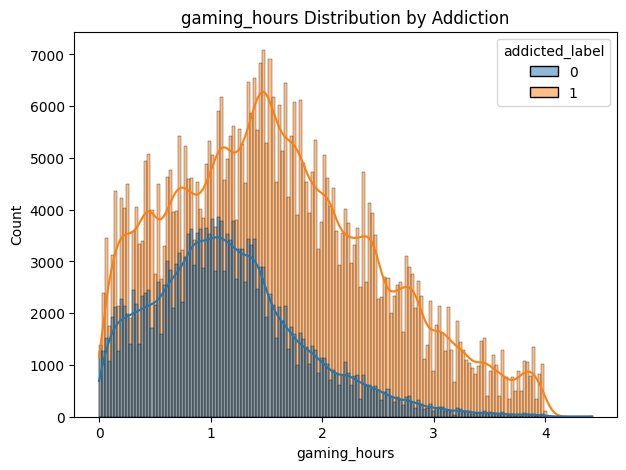

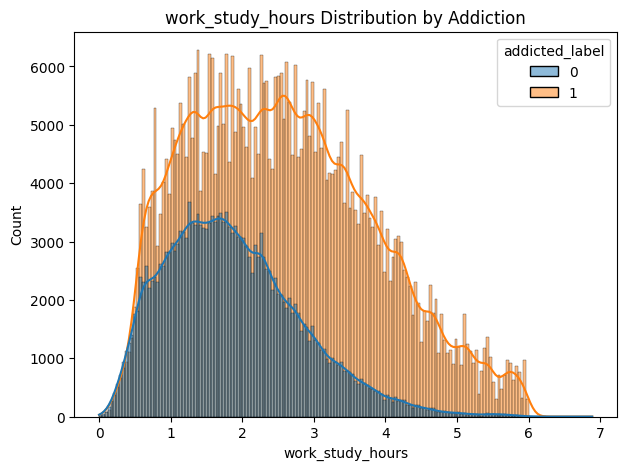

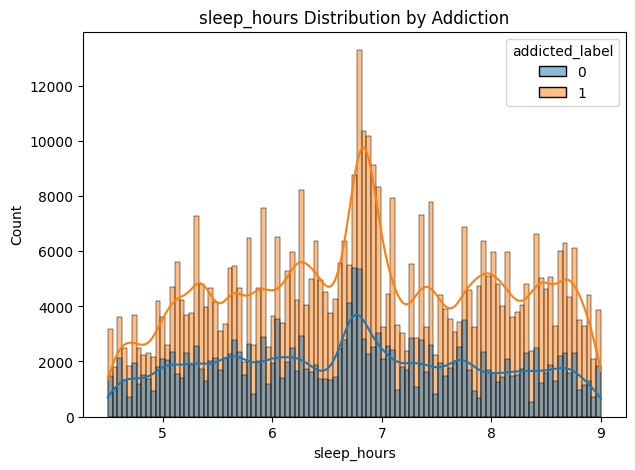

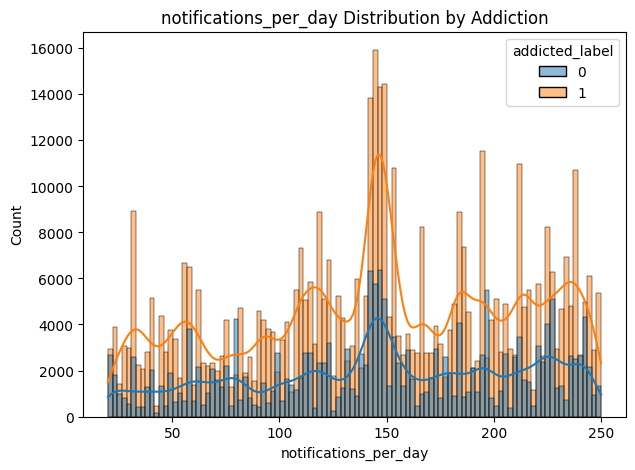

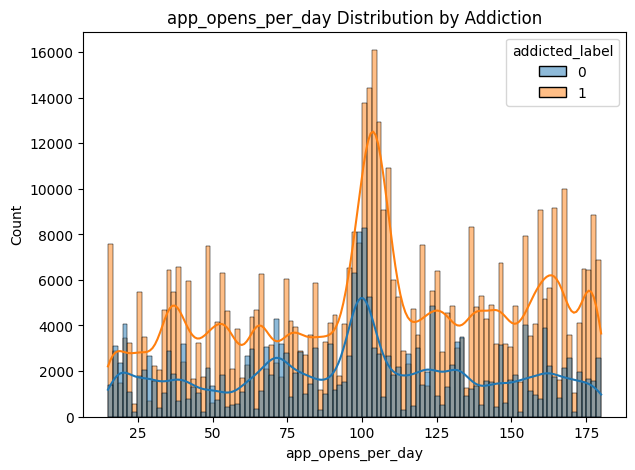

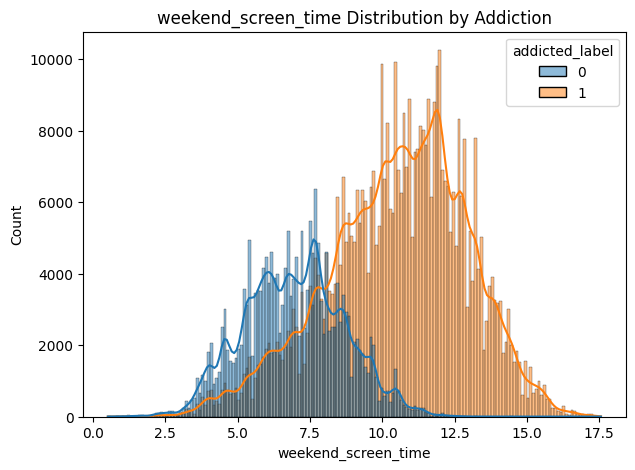

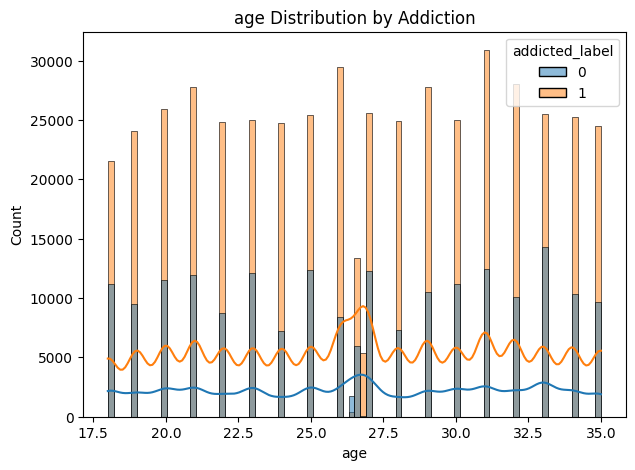

In [20]:
for col in numerical_cols:
    plt.figure(figsize=(7, 5))
    sns.histplot(data=df, x=col, hue='addicted_label', kde=True)
    plt.title(f'{col} Distribution by Addiction')
    plt.show()

In [21]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
    
]

In [22]:
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

In [23]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [24]:
df.isna().sum()

age                             0
daily_screen_time_hours         0
social_media_hours              0
gaming_hours                    0
work_study_hours                0
sleep_hours                     0
notifications_per_day           0
app_opens_per_day               0
weekend_screen_time             0
addicted_label                  0
entertainment_hours             0
entertainment_ratio             0
social_media_ratio              0
gaming_ratio                    0
work_study_ratio                0
weekend_screen_ratio            0
weekend_screen_difference       0
recreational_to_work_ratio      0
social_gaming_interaction       0
sleep_screen_ratio              0
gender_Male                     0
gender_Other                    0
gender_Unknown                  0
stress_level_Low                0
stress_level_Medium             0
stress_level_Unknown            0
academic_work_impact_Unknown    0
academic_work_impact_Yes        0
dtype: int64

In [25]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,...,social_gaming_interaction,sleep_screen_ratio,gender_Male,gender_Other,gender_Unknown,stress_level_Low,stress_level_Medium,stress_level_Unknown,academic_work_impact_Unknown,academic_work_impact_Yes
count,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,...,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000,683904.000000
mean,26.625923,7.643066,2.471838,1.459975,2.367158,6.804513,145.904755,102.634311,9.479950,0.709398,...,3.729999,1.058475,0.324316,0.314654,0.039715,0.302073,0.301807,0.074993,0.059807,0.480192
std,5.044481,2.673910,1.243133,0.871718,1.233544,1.197033,62.796052,45.349491,2.765754,0.454041,...,3.181843,0.657937,0.468119,0.464378,0.195288,0.459157,0.459042,0.263380,0.237128,0.499608
min,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000,...,0.000000,0.303797,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,5.530000,1.530343,0.800000,1.390000,5.860000,101.000000,68.000000,7.430000,0.000000,...,1.297800,0.685848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.688502,7.760000,2.350000,1.360000,2.210000,6.801965,147.000000,103.248332,9.570000,1.000000,...,2.870529,0.877358,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,31.000000,9.790000,3.290000,2.000277,3.160675,7.800000,197.000000,140.000000,11.640000,1.000000,...,5.323500,1.233400,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,35.000000,15.491169,8.000000,4.419945,6.888625,9.000000,250.000000,180.000000,17.560000,1.000000,...,29.060400,17.607843,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
X=df.drop("addicted_label",axis=1)
y=df['addicted_label']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

In [29]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
model=LogisticRegression().fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)


In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [32]:
accuracy_score(y_test,y_pred)

0.8566257106017573

In [33]:
confusion_matrix(y_test,y_pred)

array([[ 47425,  18161],
       [ 14197, 145906]])

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.72      0.75     65586
           1       0.89      0.91      0.90    160103

    accuracy                           0.86    225689
   macro avg       0.83      0.82      0.82    225689
weighted avg       0.85      0.86      0.86    225689

